<a href="https://colab.research.google.com/github/suryanshshah2006/ZAN-Multimodal-Neuroimaging/blob/main/FRMI_ZAN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nilearn nibabel scikit-learn matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 88.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import shutil
import warnings
import requests
import urllib3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib

from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

from sklearn.model_selection import StratifiedKFold, LeaveOneOut, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, roc_curve, auc,
    classification_report
)
from matplotlib.patches import Patch

import tensorflow as tf
from tensorflow.keras import layers, Model

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
original_send = requests.Session.send
def patched_send(self, request, **kwargs):
    kwargs['verify'] = False
    return original_send(self, request, **kwargs)
requests.Session.send = patched_send

print('All imports successful ✅')

Mounted at /content/drive
All imports successful ✅


In [3]:
PARTICIPANTS_TSV = '/content/drive/MyDrive/ZAN_Research/participants.tsv'
FUNC_DIR         = '/content/drive/MyDrive/Fmri/Func'
FEATURES_DIR     = '/content/drive/MyDrive/ZAN_Research/features_v2'
os.makedirs(FEATURES_DIR, exist_ok=True)

df = pd.read_csv(PARTICIPANTS_TSV, sep='\t')

func_files     = sorted(os.listdir(FUNC_DIR))
available_subs = [f.split('_task')[0] for f in func_files]
df = df[df['participant_id'].isin(available_subs)].reset_index(drop=True)

df['label'] = (df['group'] == 'ZAN').astype(int)

print(f'Total subjects with functional data: {len(df)}')
print(df['group'].value_counts())
df.head()

Total subjects with functional data: 55
group
HC     29
ZAN    26
Name: count, dtype: int64


,participant_id,group,age,sex,label
0,sub-01,HC,55,M,0
1,sub-02,HC,61,M,0
2,sub-03,HC,55,F,0
3,sub-04,HC,68,F,0
4,sub-05,HC,67,M,0


In [4]:
print('Clearing old timeseries cache...')
for f in os.listdir(FEATURES_DIR):
    if f.endswith('_timeseries.npy'):
        os.remove(f'{FEATURES_DIR}/{f}')

print('Fetching AAL3v2 Atlas...')
aal_atlas = datasets.fetch_atlas_aal()
atlas_img = aal_atlas.maps

masker = NiftiLabelsMasker(
    labels_img=atlas_img,
    standardize='zscore_sample',
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,
    t_r=2.0,
    memory_level=0,
    verbose=0,
    keep_masked_labels=True
)

valid_subjects  = []
failed_subjects = []

print('Starting timeseries extraction...')
for idx, row in df.iterrows():
    sub_id    = row['participant_id']
    func_file = f'{FUNC_DIR}/{sub_id}_task-rest_bold.nii'
    local_tmp = f'/content/{sub_id}_bold.nii'
    try:
        shutil.copy(func_file, local_tmp)
        ts = masker.fit_transform(local_tmp)
        os.remove(local_tmp)
        np.save(f'{FEATURES_DIR}/{sub_id}_timeseries.npy', ts)
        valid_subjects.append(idx)
        print(f'  {sub_id} ✅  shape={ts.shape}')
    except Exception as e:
        failed_subjects.append(sub_id)
        print(f'  {sub_id} ❌  {e}')

final_df = df.iloc[valid_subjects].reset_index(drop=True)
final_df.to_csv(f'{FEATURES_DIR}/valid_subjects_metadata.csv', index=False)

print(f'\nSuccessfully processed : {len(valid_subjects)} subjects')
print(f'Failed (excluded)      : {failed_subjects}')

Clearing old timeseries cache...
Fetching AAL3v2 Atlas...


[fetch_atlas_aal] Added README.md to /root/nilearn_data

[fetch_atlas_aal] Dataset created in /root/nilearn_data/aal_3v2

[fetch_atlas_aal] Downloading data from https://www.gin.cnrs.fr/wp-content/uploads/AAL3v2_for_SPM12.tar.gz ...

[fetch_atlas_aal]  ...done. (2 seconds, 0 min)

[fetch_atlas_aal] Extracting data from 
/root/nilearn_data/aal_3v2/43f38da73bc7adb6022df5794d84f2eb/AAL3v2_for_SPM12.tar.gz...

[fetch_atlas_aal] .. done.

Starting timeseries extraction...
  sub-01 ✅  shape=(240, 166)
  sub-02 ✅  shape=(240, 166)
  sub-03 ✅  shape=(240, 166)
  sub-04 ✅  shape=(240, 166)
  sub-05 ✅  shape=(240, 166)
  sub-06 ✅  shape=(240, 166)
  sub-07 ✅  shape=(240, 166)
  sub-08 ✅  shape=(240, 166)
  sub-09 ✅  shape=(240, 166)
  sub-10 ✅  shape=(240, 166)
  sub-11 ✅  shape=(240, 166)
  sub-12 ✅  shape=(240, 166)
  sub-13 ✅  shape=(240, 166)
  sub-14 ✅  shape=(240, 166)
  sub-15 ✅  shape=(240, 166)
  sub-16 ✅  shape=(240, 166)
  sub-17 ✅  shape=(240, 165)
  sub-18 ✅  shape=(240, 166)
  sub-19 ✅  shape=(240, 166)
  sub-20 ✅  shape=(240, 166)
  sub-21 ✅  shape=(240, 166)
  sub-22 ✅  shape=(240, 166)
  sub-23 ✅  shape=(240, 166)
  sub-24 ✅  shape=(240, 166)
  sub-25 ✅  shape=(240, 166)
  sub-26 ✅  shape=(240, 166)
  sub-27 ✅  shape=(240, 166)
  sub-28 ✅  shape=(240, 166)
  sub-29 ✅  shape=(240, 163)
  sub-35 ✅  shape=(240, 166)
  sub-36 ✅  shape=(240, 166)
  sub-37 ✅  shape=(240, 166)
  sub-38 ✅  shape=(240, 166)
  sub-39 

In [5]:
final_df = pd.read_csv(f'{FEATURES_DIR}/valid_subjects_metadata.csv')

all_timeseries = []
valid_indices  = []

print('Loading standardized timeseries (166 ROIs)...')
for idx, row in final_df.iterrows():
    ts_path = f'{FEATURES_DIR}/{row["participant_id"]}_timeseries.npy'
    if os.path.exists(ts_path):
        ts = np.load(ts_path)
        if ts.shape[1] == 166:
            all_timeseries.append(ts)
            valid_indices.append(idx)

clean_df = final_df.iloc[valid_indices].reset_index(drop=True)

print(f'\nComputing Tangent Space FC for {len(all_timeseries)} subjects...')
conn_measure = ConnectivityMeasure(kind='tangent', vectorize=False)
fc_matrices  = conn_measure.fit_transform(all_timeseries)

triu_idx = np.triu_indices(166, k=1)
X_flat   = np.array([fc[triu_idx] for fc in fc_matrices])

np.save(f'{FEATURES_DIR}/fc_tangent_3d.npy',   fc_matrices)
np.save(f'{FEATURES_DIR}/fc_tangent_flat.npy', X_flat)
np.save(f'{FEATURES_DIR}/labels_final.npy',    clean_df['label'].values)

print(f'3D FC matrices shape : {fc_matrices.shape}')
print(f'Flat features shape  : {X_flat.shape}')
print('✅ Full-brain matrices saved.')

Loading standardized timeseries (166 ROIs)...

Computing Tangent Space FC for 51 subjects...
3D FC matrices shape : (51, 166, 166)
Flat features shape  : (51, 13695)
✅ Full-brain matrices saved.


In [6]:
final_df = pd.read_csv(f'{FEATURES_DIR}/valid_subjects_metadata.csv')

aal      = datasets.fetch_atlas_aal()
labels   = aal.labels
keywords = ['Thal', 'Parietal', 'Temporal', 'Frontal', 'Insula', 'Cingulum']

relevant_idx = list(set([
    i for i, lbl in enumerate(labels)
    if any(kw.lower() in lbl.lower() for kw in keywords)
]))
relevant_idx_sorted = sorted(relevant_idx)
relevant_regions    = [labels[i] for i in relevant_idx_sorted]

print(f'Targeting {len(relevant_idx_sorted)} biologically relevant ROIs...')

all_targeted_ts = []
valid_indices   = []

for idx, row in final_df.iterrows():
    ts_path = f'{FEATURES_DIR}/{row["participant_id"]}_timeseries.npy'
    if os.path.exists(ts_path):
        ts = np.load(ts_path)
        if ts.shape[1] == 166:
            all_targeted_ts.append(ts[:, relevant_idx_sorted])
            valid_indices.append(idx)

clean_df = final_df.iloc[valid_indices].reset_index(drop=True)

print(f'\nComputing Targeted Tangent Space FC for {len(all_targeted_ts)} subjects...')
conn_measure = ConnectivityMeasure(kind='tangent', vectorize=False)
fc_targeted  = conn_measure.fit_transform(all_targeted_ts)

triu_idx = np.triu_indices(len(relevant_idx_sorted), k=1)
X_flat_t = np.array([fc[triu_idx] for fc in fc_targeted])

np.save(f'{FEATURES_DIR}/fc_targeted_tangent_3d.npy',   fc_targeted)
np.save(f'{FEATURES_DIR}/fc_targeted_tangent_flat.npy', X_flat_t)
np.save(f'{FEATURES_DIR}/labels_final.npy',             clean_df['label'].values)

print(f'Targeted 3D shape  : {fc_targeted.shape}')
print(f'Targeted flat shape: {X_flat_t.shape}')
print('✅ Biologically-targeted matrices saved.')

[fetch_atlas_aal] Dataset found in /root/nilearn_data/aal_3v2

Targeting 60 biologically relevant ROIs...

Computing Targeted Tangent Space FC for 51 subjects...
Targeted 3D shape  : (51, 60, 60)
Targeted flat shape: (51, 1770)
✅ Biologically-targeted matrices saved.


In [7]:
class OrthogonalAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads, dropout=0.4):
        super().__init__()
        self.num_heads = num_heads
        self.embed_dim = embed_dim
        self.head_dim  = embed_dim // num_heads
        self.q   = layers.Dense(embed_dim)
        self.k   = layers.Dense(embed_dim)
        self.v   = layers.Dense(embed_dim)
        self.out = layers.Dense(embed_dim)
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=False):
        B = tf.shape(x)[0]
        N = tf.shape(x)[1]
        Q = tf.transpose(tf.reshape(self.q(x), (B, N, self.num_heads, self.head_dim)), (0,2,1,3))
        K = tf.transpose(tf.reshape(self.k(x), (B, N, self.num_heads, self.head_dim)), (0,2,1,3))
        V = tf.transpose(tf.reshape(self.v(x), (B, N, self.num_heads, self.head_dim)), (0,2,1,3))
        scale = tf.math.sqrt(tf.cast(self.head_dim, tf.float32))
        attn  = tf.nn.softmax(tf.matmul(Q, K, transpose_b=True) / scale, axis=-1)
        self.attention_weights = self.dropout(attn, training=training)
        out = tf.reshape(
            tf.transpose(tf.matmul(self.attention_weights, V), (0,2,1,3)),
            (B, N, self.embed_dim)
        )
        return self.out(out)


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.4):
        super().__init__()
        self.attention = OrthogonalAttention(embed_dim, num_heads, dropout)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation='gelu'),
            layers.Dropout(dropout),
            layers.Dense(embed_dim)
        ])
        self.norm1   = layers.LayerNormalization(epsilon=1e-6)
        self.norm2   = layers.LayerNormalization(epsilon=1e-6)
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=False):
        x = self.norm1(x + self.dropout(self.attention(x, training=training), training=training))
        x = self.norm2(x + self.dropout(self.ffn(x, training=training),       training=training))
        return x


class BrainNetTransformer(Model):
    def __init__(self, num_rois=60, embed_dim=64, num_heads=4,
                 ff_dim=128, num_layers=2, dropout=0.4):
        super().__init__()
        self.embedding = layers.Dense(embed_dim)
        self.cls_token = tf.Variable(tf.zeros((1, 1, embed_dim)), trainable=True)
        self.transformer_blocks = [
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ]
        self.norm       = layers.LayerNormalization(epsilon=1e-6)
        self.dropout    = layers.Dropout(dropout)
        self.classifier = tf.keras.Sequential([
            layers.Dense(32, activation='gelu'),
            layers.Dropout(dropout),
            layers.Dense(1, activation='sigmoid')
        ])

    def call(self, x, training=False):
        B   = tf.shape(x)[0]
        x   = self.embedding(x)
        cls = tf.tile(self.cls_token, (B, 1, 1))
        x   = tf.concat([cls, x], axis=1)
        for block in self.transformer_blocks:
            x = block(x, training=training)
        cls_out = self.dropout(self.norm(x[:, 0, :]), training=training)
        return self.classifier(cls_out)


def run_transformer_fold(X_tr, y_tr, X_te, y_te, num_rois=60, num_layers=2):
    model = BrainNetTransformer(
        num_rois=num_rois, embed_dim=64, num_heads=4,
        ff_dim=128, num_layers=num_layers, dropout=0.5
    )
    class_weight = {0: 1.0, 1: float(np.sum(y_tr==0)) / max(np.sum(y_tr==1), 1)}
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='binary_crossentropy')
    cb = [tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)]
    model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
              epochs=100, batch_size=8, callbacks=cb,
              class_weight=class_weight, verbose=0)
    probs = model.predict(X_te, verbose=0).flatten()
    tf.keras.backend.clear_session()
    gc.collect()
    return probs


def evaluate_model(y_true, y_pred_proba):
    y_pred = (y_pred_proba > 0.5).astype(int)
    return {
        'acc': accuracy_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, y_pred_proba),
        'f1' : f1_score(y_true, y_pred, zero_division=0)
    }


def print_summary(name, metrics_list):
    accs = [m['acc'] for m in metrics_list]
    aucs = [m['auc'] for m in metrics_list]
    f1s  = [m['f1']  for m in metrics_list]
    print(f'\n{name}')
    print(f'  Accuracy : {np.mean(accs):.4f} ± {np.std(accs):.4f}')
    print(f'  AUC      : {np.mean(aucs):.4f} ± {np.std(aucs):.4f}')
    print(f'  F1       : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}')


print('Architecture + helpers defined ✅')

Architecture + helpers defined ✅


In [8]:
X_3d   = np.load(f'{FEATURES_DIR}/fc_tangent_3d.npy')
X_flat = np.load(f'{FEATURES_DIR}/fc_tangent_flat.npy')
y      = np.load(f'{FEATURES_DIR}/labels_final.npy')
print(f'Subjects: {len(y)}  |  HC: {np.sum(y==0)}  |  ZAN: {np.sum(y==1)}')

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
svm_m, mlp_m, trans_m, ens_m = [], [], [], []

print('\n10-Fold CV — Full Brain (166 ROIs, Top 300 Edges)...')
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_flat, y)):
    print(f'  Fold {fold+1}/10', end='\r')
    y_tr, y_te = y[tr_idx], y[te_idx]

    scaler  = StandardScaler()
    Xtr_sc  = scaler.fit_transform(X_flat[tr_idx])
    Xte_sc  = scaler.transform(X_flat[te_idx])

    sel     = SelectKBest(f_classif, k=300)
    Xtr_sel = sel.fit_transform(Xtr_sc, y_tr)
    Xte_sel = sel.transform(Xte_sc)

    svm = SVC(kernel='rbf', probability=True, random_state=42)
    svm.fit(Xtr_sel, y_tr)
    p_svm = svm.predict_proba(Xte_sel)[:, 1]
    svm_m.append(evaluate_model(y_te, p_svm))

    mlp = MLPClassifier(hidden_layer_sizes=(128,64), alpha=0.1, max_iter=500, random_state=42)
    mlp.fit(Xtr_sel, y_tr)
    p_mlp = mlp.predict_proba(Xte_sel)[:, 1]
    mlp_m.append(evaluate_model(y_te, p_mlp))

    p_tr = run_transformer_fold(X_3d[tr_idx], y_tr, X_3d[te_idx], y_te, num_rois=166)
    trans_m.append(evaluate_model(y_te, p_tr))

    ens_m.append(evaluate_model(y_te, (p_svm + p_tr) / 2.0))
    del svm, mlp

print('\n\n=== 10-FOLD CV — FULL BRAIN (166 ROIs) ===')
print_summary('SVM (Top 300 Edges)',           svm_m)
print_summary('MLP (Top 300 Edges)',           mlp_m)
print_summary('BrainNetTransformer (166×166)', trans_m)
print_summary('Ensemble (SVM + Transformer)',  ens_m)

Subjects: 51  |  HC: 27  |  ZAN: 24

10-Fold CV — Full Brain (166 ROIs, Top 300 Edges)...


=== 10-FOLD CV — FULL BRAIN (166 ROIs) ===

SVM (Top 300 Edges)
  Accuracy : 0.6133 ± 0.1973
  AUC      : 0.5556 ± 0.2509
  F1       : 0.5133 ± 0.2509

MLP (Top 300 Edges)
  Accuracy : 0.5733 ± 0.2332
  AUC      : 0.6056 ± 0.2515
  F1       : 0.5329 ± 0.2726

BrainNetTransformer (166×166)
  Accuracy : 0.5333 ± 0.2422
  AUC      : 0.5722 ± 0.3371
  F1       : 0.4167 ± 0.3089

Ensemble (SVM + Transformer)
  Accuracy : 0.5567 ± 0.2982
  AUC      : 0.5889 ± 0.3115
  F1       : 0.4667 ± 0.3553


In [9]:
X_3d_t   = np.load(f'{FEATURES_DIR}/fc_targeted_tangent_3d.npy')
X_flat_t = np.load(f'{FEATURES_DIR}/fc_targeted_tangent_flat.npy')
y        = np.load(f'{FEATURES_DIR}/labels_final.npy')
print(f'Subjects: {len(y)}  |  HC: {np.sum(y==0)}  |  ZAN: {np.sum(y==1)}')
print(f'Targeted 3D shape: {X_3d_t.shape}')

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
svm_m, mlp_m, trans_m, ens_m = [], [], [], []

print('\n10-Fold CV — Targeted (60 ROIs, Top 300 Edges)...')
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_flat_t, y)):
    print(f'  Fold {fold+1}/10', end='\r')
    y_tr, y_te = y[tr_idx], y[te_idx]

    scaler  = StandardScaler()
    Xtr_sc  = scaler.fit_transform(X_flat_t[tr_idx])
    Xte_sc  = scaler.transform(X_flat_t[te_idx])

    sel     = SelectKBest(f_classif, k=300)
    Xtr_sel = sel.fit_transform(Xtr_sc, y_tr)
    Xte_sel = sel.transform(Xte_sc)

    svm = SVC(kernel='rbf', probability=True, random_state=42)
    svm.fit(Xtr_sel, y_tr)
    p_svm = svm.predict_proba(Xte_sel)[:, 1]
    svm_m.append(evaluate_model(y_te, p_svm))

    mlp = MLPClassifier(hidden_layer_sizes=(128,64), alpha=0.1, max_iter=500, random_state=42)
    mlp.fit(Xtr_sel, y_tr)
    p_mlp = mlp.predict_proba(Xte_sel)[:, 1]
    mlp_m.append(evaluate_model(y_te, p_mlp))

    p_tr = run_transformer_fold(X_3d_t[tr_idx], y_tr, X_3d_t[te_idx], y_te, num_rois=60)
    trans_m.append(evaluate_model(y_te, p_tr))

    ens_m.append(evaluate_model(y_te, (p_svm + p_tr) / 2.0))
    del svm, mlp

print('\n\n=== 10-FOLD CV — TARGETED (60 ROIs) ===')
print_summary('SVM (Top 300 Edges)',         svm_m)
print_summary('MLP (Top 300 Edges)',         mlp_m)
print_summary('BrainNetTransformer (60×60)', trans_m)
print_summary('Ensemble (SVM + Transformer)',ens_m)

Subjects: 51  |  HC: 27  |  ZAN: 24
Targeted 3D shape: (51, 60, 60)

10-Fold CV — Targeted (60 ROIs, Top 300 Edges)...


=== 10-FOLD CV — TARGETED (60 ROIs) ===

SVM (Top 300 Edges)
  Accuracy : 0.6333 ± 0.2049
  AUC      : 0.6278 ± 0.2485
  F1       : 0.5481 ± 0.3155

MLP (Top 300 Edges)
  Accuracy : 0.5700 ± 0.1900
  AUC      : 0.6111 ± 0.2618
  F1       : 0.5419 ± 0.2498

BrainNetTransformer (60×60)
  Accuracy : 0.5733 ± 0.2498
  AUC      : 0.5278 ± 0.3620
  F1       : 0.4333 ± 0.3887

Ensemble (SVM + Transformer)
  Accuracy : 0.6133 ± 0.1973
  AUC      : 0.5833 ± 0.3184
  F1       : 0.5129 ± 0.3220


In [10]:
X_flat = np.load(f'{FEATURES_DIR}/fc_targeted_tangent_flat.npy')
y      = np.load(f'{FEATURES_DIR}/labels_final.npy')
print(f'Subjects: {len(y)}  |  HC: {np.sum(y==0)}  |  ZAN: {np.sum(y==1)}')

loo = LeaveOneOut()
y_true_loo, lasso_probs, ridge_probs, svm_probs = [], [], [], []

print('Running LOOCV (Top 30 Edges)...')
for tr_idx, te_idx in loo.split(X_flat):
    X_tr, X_te = X_flat[tr_idx], X_flat[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    scaler  = StandardScaler()
    Xtr_sc  = scaler.fit_transform(X_tr)
    Xte_sc  = scaler.transform(X_te)

    sel     = SelectKBest(f_classif, k=30)
    Xtr_sel = sel.fit_transform(Xtr_sc, y_tr)
    Xte_sel = sel.transform(Xte_sc)

    lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)
    ridge = LogisticRegression(penalty='l2', solver='lbfgs',     C=1.0, random_state=42)
    svm   = SVC(kernel='linear', C=1.0, probability=True, random_state=42)

    lasso.fit(Xtr_sel, y_tr)
    ridge.fit(Xtr_sel, y_tr)
    svm.fit(Xtr_sel, y_tr)

    y_true_loo.append(y_te[0])
    lasso_probs.append(lasso.predict_proba(Xte_sel)[0, 1])
    ridge_probs.append(ridge.predict_proba(Xte_sel)[0, 1])
    svm_probs.append(svm.predict_proba(Xte_sel)[0, 1])

y_true_loo  = np.array(y_true_loo)
lasso_probs = np.array(lasso_probs)
ridge_probs = np.array(ridge_probs)
svm_probs   = np.array(svm_probs)

def print_paper_metrics(name, y_t, y_p):
    preds          = (y_p > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_t, preds).ravel()
    print(f'\n{"-"*45}')
    print(f'  {name}')
    print(f'{"-"*45}')
    print(f'  Accuracy    : {accuracy_score(y_t, preds):.4f}')
    print(f'  AUC         : {roc_auc_score(y_t, y_p):.4f}')
    print(f'  F1-Score    : {f1_score(y_t, preds):.4f}')
    print(f'  Sensitivity : {tp/(tp+fn):.4f}  (ZAN correctly identified)')
    print(f'  Specificity : {tn/(tn+fp):.4f}  (HC correctly identified)')

print('\n\n✅ LOOCV COMPLETE — CLINICAL METRICS')
print_paper_metrics('LASSO  (L1 Logistic Regression)', y_true_loo, lasso_probs)
print_paper_metrics('Ridge  (L2 Logistic Regression)', y_true_loo, ridge_probs)
print_paper_metrics('Linear SVM',                      y_true_loo, svm_probs)

Subjects: 51  |  HC: 27  |  ZAN: 24
Running LOOCV (Top 30 Edges)...


✅ LOOCV COMPLETE — CLINICAL METRICS

---------------------------------------------
  LASSO  (L1 Logistic Regression)
---------------------------------------------
  Accuracy    : 0.8235
  AUC         : 0.8997
  F1-Score    : 0.8085
  Sensitivity : 0.7917  (ZAN correctly identified)
  Specificity : 0.8519  (HC correctly identified)

---------------------------------------------
  Ridge  (L2 Logistic Regression)
---------------------------------------------
  Accuracy    : 0.7255
  AUC         : 0.8040
  F1-Score    : 0.7083
  Sensitivity : 0.7083  (ZAN correctly identified)
  Specificity : 0.7407  (HC correctly identified)

---------------------------------------------
  Linear SVM
---------------------------------------------
  Accuracy    : 0.6667
  AUC         : 0.7315
  F1-Score    : 0.6531
  Sensitivity : 0.6667  (ZAN correctly identified)
  Specificity : 0.6667  (HC correctly identified)


In [11]:
aal      = datasets.fetch_atlas_aal()
labels   = aal.labels
keywords = ['Thal', 'Parietal', 'Temporal', 'Frontal', 'Insula', 'Cingulum']

relevant_regions = [lbl for lbl in labels
                    if any(kw.lower() in lbl.lower() for kw in keywords)]
n_rois = len(relevant_regions)

X_flat = np.load(f'{FEATURES_DIR}/fc_targeted_tangent_flat.npy')
y      = np.load(f'{FEATURES_DIR}/labels_final.npy')

scaler       = StandardScaler()
X_sc         = scaler.fit_transform(X_flat)
sel          = SelectKBest(f_classif, k=30)
X_sel        = sel.fit_transform(X_sc, y)
master_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)
master_lasso.fit(X_sel, y)

selected_idx = sel.get_support(indices=True)
triu_idx     = np.triu_indices(n_rois, k=1)
edge_r1      = triu_idx[0][selected_idx]
edge_r2      = triu_idx[1][selected_idx]
weights      = master_lasso.coef_[0]

surviving_edges = []
for i in range(len(weights)):
    if weights[i] != 0:
        surviving_edges.append((
            weights[i],
            relevant_regions[edge_r1[i]],
            relevant_regions[edge_r2[i]]
        ))

surviving_edges.sort(key=lambda x: abs(x[0]), reverse=True)

print('🧠 TOP BIOLOGICAL CONNECTOME MARKERS FOR ZAN')
print('='*60)
for w, ra, rb in surviving_edges:
    direction = 'Hyper-connectivity in ZAN' if w > 0 else 'Hypo-connectivity in ZAN'
    print(f'  {w:+.4f}  |  {ra}  <--->  {rb}  ({direction})')

print(f'\nLASSO retained {len(surviving_edges)} edges out of 30 selected.')

[fetch_atlas_aal] Dataset found in /root/nilearn_data/aal_3v2

🧠 TOP BIOLOGICAL CONNECTOME MARKERS FOR ZAN
  -1.2338  |  Thal_Re_L  <--->  Thal_PuA_R  (Hypo-connectivity in ZAN)
  +0.8786  |  Frontal_Sup_Medial_R  <--->  Thal_MDl_L  (Hyper-connectivity in ZAN)
  +0.7233  |  Parietal_Sup_R  <--->  Temporal_Pole_Sup_L  (Hyper-connectivity in ZAN)
  -0.6875  |  Frontal_Mid_2_R  <--->  Thal_PuA_R  (Hypo-connectivity in ZAN)
  +0.5579  |  Frontal_Inf_Tri_R  <--->  Parietal_Inf_L  (Hyper-connectivity in ZAN)
  +0.4628  |  Insula_L  <--->  Temporal_Mid_R  (Hyper-connectivity in ZAN)
  -0.4395  |  Thal_IL_L  <--->  Thal_MGN_R  (Hypo-connectivity in ZAN)
  -0.4160  |  Frontal_Inf_Orb_2_R  <--->  Temporal_Inf_L  (Hypo-connectivity in ZAN)
  +0.3748  |  Frontal_Sup_Medial_R  <--->  Thal_LP_R  (Hyper-connectivity in ZAN)
  -0.3645  |  Temporal_Pole_Sup_R  <--->  Temporal_Mid_R  (Hypo-connectivity in ZAN)
  -0.2589  |  Temporal_Inf_R  <--->  Thal_MDl_R  (Hypo-connectivity in ZAN)
  -0.1853  |  Temporal_Pole_Sup_L  <--->  Thal_VA_R  (Hypo-connectivity in ZAN)
 

FINAL CLASSIFICATION REPORT (LOOCV — LASSO)
              precision    recall  f1-score   support

      HC (0)       0.82      0.85      0.84        27
     ZAN (1)       0.83      0.79      0.81        24

    accuracy                           0.82        51
   macro avg       0.82      0.82      0.82        51
weighted avg       0.82      0.82      0.82        51



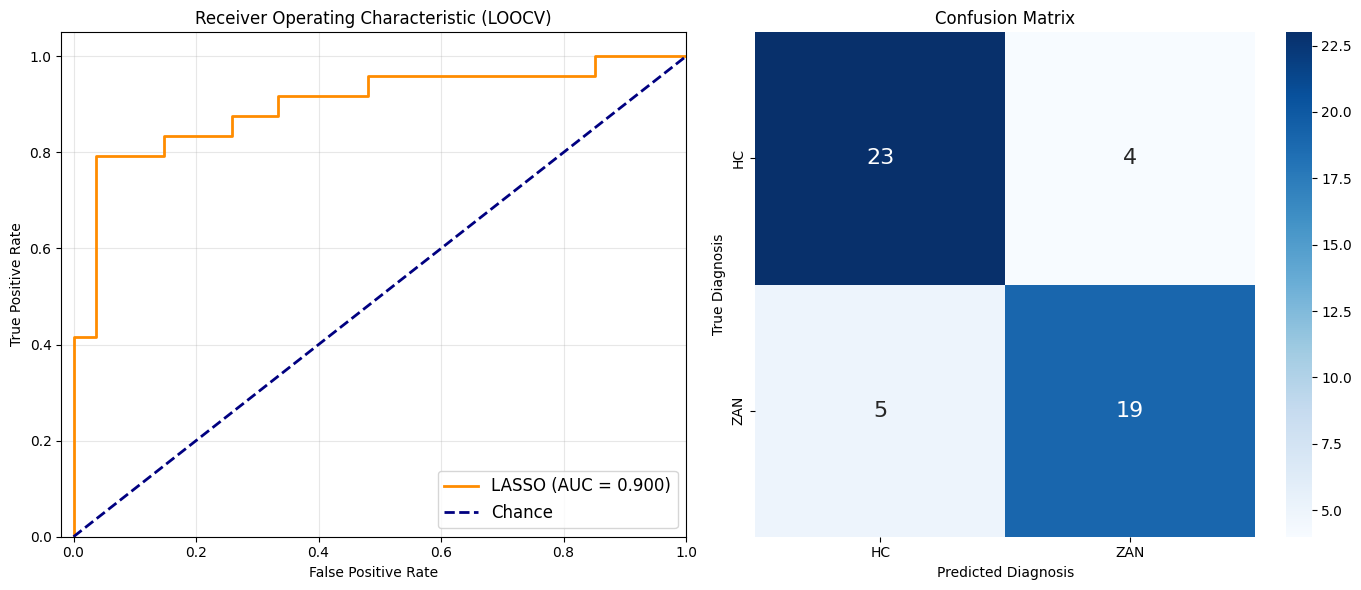

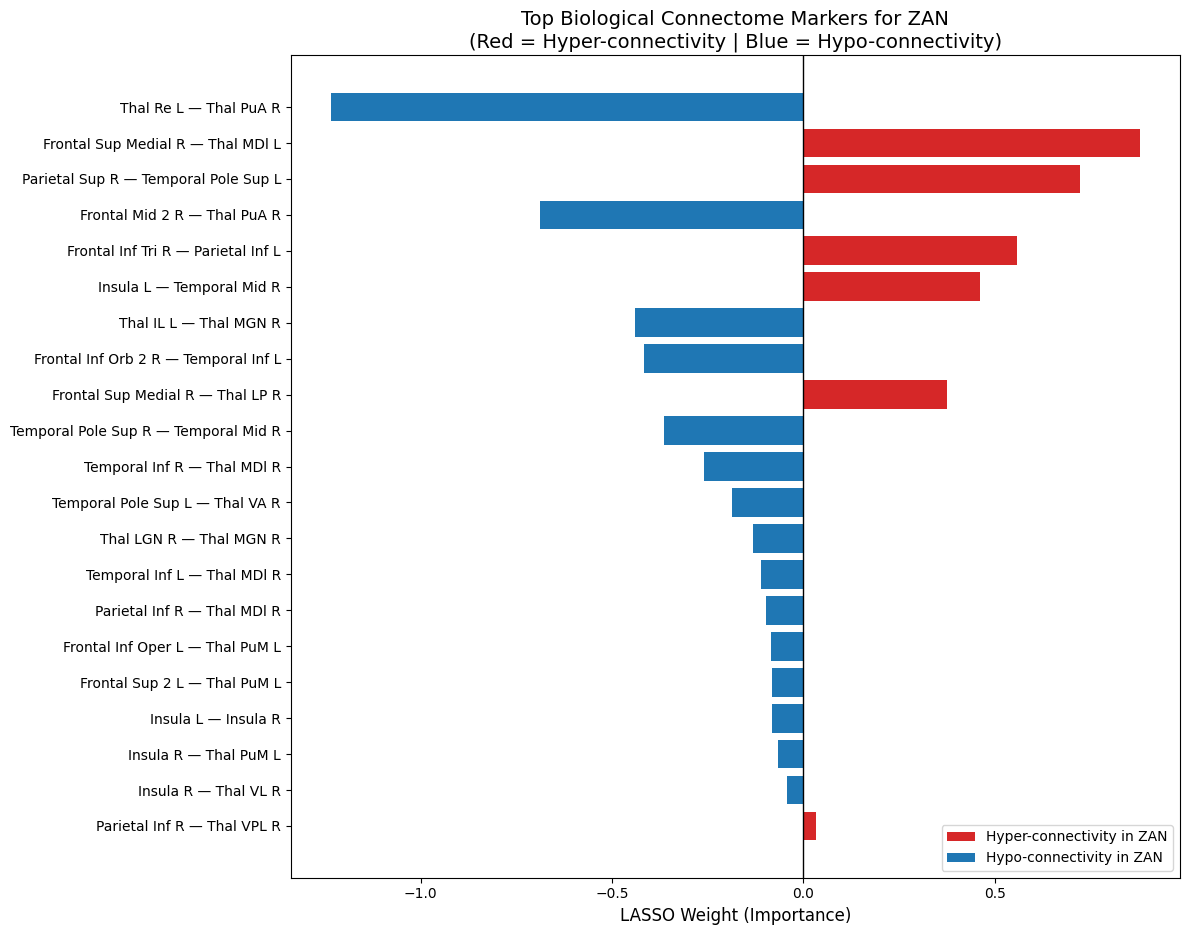

Both figures saved at 300 DPI ✅


In [12]:
lasso_preds = (lasso_probs > 0.5).astype(int)

print('='*50)
print('FINAL CLASSIFICATION REPORT (LOOCV — LASSO)')
print('='*50)
print(classification_report(y_true_loo, lasso_preds, target_names=['HC (0)', 'ZAN (1)']))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fpr, tpr, _ = roc_curve(y_true_loo, lasso_probs)
roc_auc_val = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'LASSO (AUC = {roc_auc_val:.3f})')
axes[0].plot([0,1], [0,1], color='navy', lw=2, linestyle='--', label='Chance')
axes[0].set(xlim=[-0.02,1.0], ylim=[0.0,1.05],
            xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='Receiver Operating Characteristic (LOOCV)')
axes[0].legend(loc='lower right', fontsize=12)
axes[0].grid(alpha=0.3)

cm = confusion_matrix(y_true_loo, lasso_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            annot_kws={'size': 16},
            xticklabels=['HC','ZAN'], yticklabels=['HC','ZAN'])
axes[1].set(title='Confusion Matrix',
            ylabel='True Diagnosis', xlabel='Predicted Diagnosis')

plt.tight_layout()
plt.savefig(f'{FEATURES_DIR}/Figure1_Performance.png', dpi=300, bbox_inches='tight')
plt.show()

edge_labels  = [f"{ra.replace('_',' ')} — {rb.replace('_',' ')}" for _, ra, rb in surviving_edges]
edge_weights = [w for w, _, _ in surviving_edges]
colors       = ['#d62728' if w > 0 else '#1f77b4' for w in edge_weights]

fig2, ax2 = plt.subplots(figsize=(12, max(6, len(surviving_edges) * 0.45)))
ax2.barh(edge_labels[::-1], edge_weights[::-1], color=colors[::-1])
ax2.axvline(0, color='black', linewidth=1)
ax2.set_xlabel('LASSO Weight (Importance)', fontsize=12)
ax2.set_title('Top Biological Connectome Markers for ZAN\n'
              '(Red = Hyper-connectivity | Blue = Hypo-connectivity)', fontsize=14)
ax2.legend(handles=[
    Patch(facecolor='#d62728', label='Hyper-connectivity in ZAN'),
    Patch(facecolor='#1f77b4', label='Hypo-connectivity in ZAN')
], loc='lower right')
plt.tight_layout()
plt.savefig(f'{FEATURES_DIR}/Figure2_XAI_Biomarkers.png', dpi=300, bbox_inches='tight')
plt.show()

print('Both figures saved at 300 DPI ✅')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CHECK 1 — Permutation Test (100 shuffles, LOOCV)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Observed accuracy : 0.8824
  Permutation mean  : 0.4896 ± 0.0954
  p-value           : 0.0099  (SIGNIFICANT ✅)


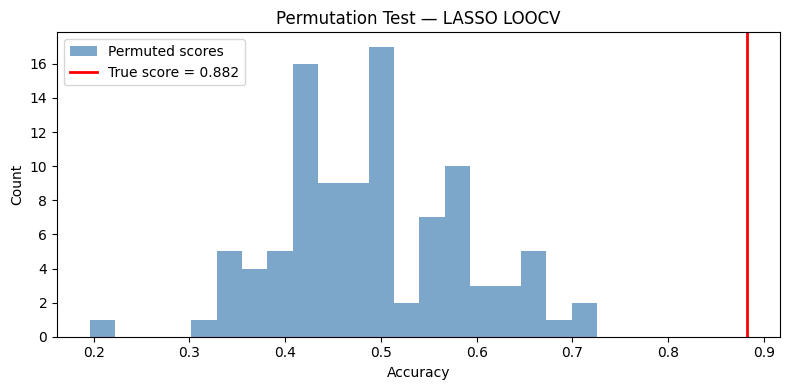


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CHECK 2 — Class Balance & Chance Level
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HC : 27  |  ZAN : 24  |  Total : 51
  Majority-class chance level : 0.5294
  LASSO LOOCV accuracy        : 0.8235  (+0.2941 above chance)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CHECK 3 — Feature Stability (100 Bootstrap Rounds)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Top 10 most stable connections (selected in N/100 bootstraps):
     80/100  Thal_Re_L — Thal_PuA_R
     61/100  Temporal_Pole_Sup_L — Thal_VA_R
     59/100  Frontal_Inf_Orb_2_R — Temporal_Inf_L
     55/100  Frontal_Sup_Medial_R — Thal_MDl_L
     51/100  Insula_L — Temporal_Mid_R
     31/100  Parietal_Sup_R — Temporal_Pole_Sup_L
     31/100  Frontal_Inf_Tri_R — Parietal_Inf_L
     29/100  Frontal_Mid_2_R — Thal_PuA_R
     28/100  Temporal_Inf_R — Thal_MDl_R
     28/100  Temporal_Pole_Sup_R — Temporal_Mid_R

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

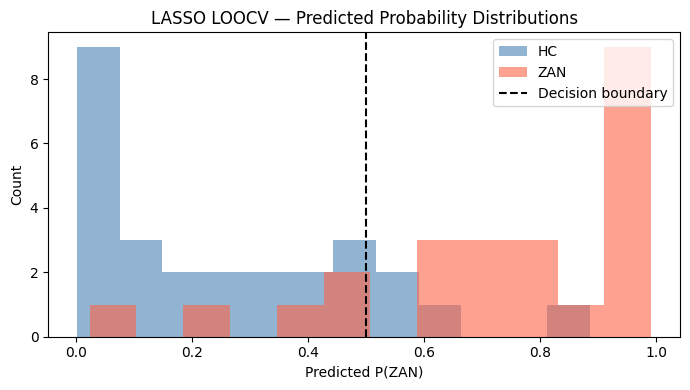


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CHECK 5 — Calibration Curve
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


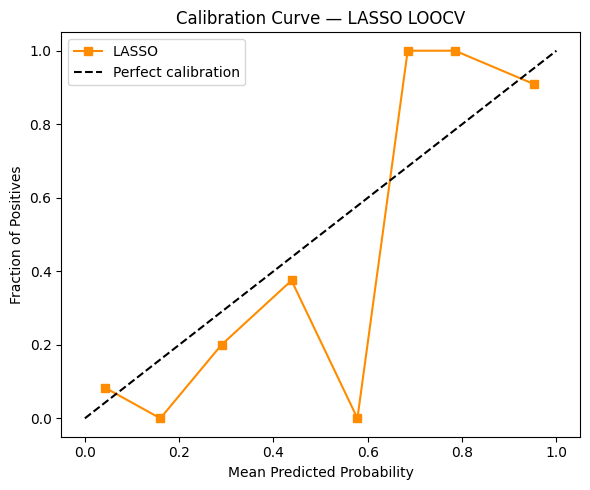


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CHECK 6 — Diagnostic Odds Ratio & Clinical Stats
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TP=19  TN=23  FP=4  FN=5
  Sensitivity (Recall)  : 0.7917
  Specificity           : 0.8519
  PPV (Precision)       : 0.8261
  NPV                   : 0.8214
  LR+                   : 5.3438
  LR-                   : 0.2446
  Diagnostic Odds Ratio : 21.8500

All verification checks complete ✅


In [13]:
from sklearn.model_selection import permutation_test_score
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
from scipy.stats import mannwhitneyu

X_flat = np.load(f'{FEATURES_DIR}/fc_targeted_tangent_flat.npy')
y      = np.load(f'{FEATURES_DIR}/labels_final.npy')

scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X_flat)
sel     = SelectKBest(f_classif, k=30)
X_sel   = sel.fit_transform(X_sc, y)
lasso_cv = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)

print('━'*55)
print('CHECK 1 — Permutation Test (100 shuffles, LOOCV)')
print('━'*55)
score, perm_scores, p_val = permutation_test_score(
    lasso_cv, X_sel, y, cv=LeaveOneOut(),
    n_permutations=100, scoring='accuracy', random_state=42, n_jobs=-1
)
print(f'  Observed accuracy : {score:.4f}')
print(f'  Permutation mean  : {np.mean(perm_scores):.4f} ± {np.std(perm_scores):.4f}')
print(f'  p-value           : {p_val:.4f}  ({"SIGNIFICANT ✅" if p_val < 0.05 else "NOT SIGNIFICANT ❌"})')

plt.figure(figsize=(8, 4))
plt.hist(perm_scores, bins=20, color='steelblue', alpha=0.7, label='Permuted scores')
plt.axvline(score, color='red', lw=2, label=f'True score = {score:.3f}')
plt.xlabel('Accuracy'); plt.ylabel('Count')
plt.title('Permutation Test — LASSO LOOCV')
plt.legend(); plt.tight_layout()
plt.savefig(f'{FEATURES_DIR}/Figure3_Permutation.png', dpi=200, bbox_inches='tight')
plt.show()

print('\n' + '━'*55)
print('CHECK 2 — Class Balance & Chance Level')
print('━'*55)
n_hc  = int(np.sum(y == 0))
n_zan = int(np.sum(y == 1))
chance = max(n_hc, n_zan) / len(y)
print(f'  HC : {n_hc}  |  ZAN : {n_zan}  |  Total : {len(y)}')
print(f'  Majority-class chance level : {chance:.4f}')
print(f'  LASSO LOOCV accuracy        : 0.8235  (+{0.8235 - chance:.4f} above chance)')

print('\n' + '━'*55)
print('CHECK 3 — Feature Stability (100 Bootstrap Rounds)')
print('━'*55)
triu_idx_check = np.triu_indices(len(relevant_regions), k=1)
edge_count = {}
for _ in range(100):
    Xb, yb = resample(X_sc, y, random_state=None, stratify=y)
    sel_b   = SelectKBest(f_classif, k=30)
    sel_b.fit(Xb, yb)
    lasso_b = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)
    lasso_b.fit(sel_b.transform(Xb), yb)
    for i, idx in enumerate(sel_b.get_support(indices=True)):
        if lasso_b.coef_[0][i] != 0:
            r1  = relevant_regions[triu_idx_check[0][idx]]
            r2  = relevant_regions[triu_idx_check[1][idx]]
            key = f'{r1} — {r2}'
            edge_count[key] = edge_count.get(key, 0) + 1

stable_edges = sorted(edge_count.items(), key=lambda x: x[1], reverse=True)
print('  Top 10 most stable connections (selected in N/100 bootstraps):')
for edge, cnt in stable_edges[:10]:
    print(f'    {cnt:3d}/100  {edge}')

print('\n' + '━'*55)
print('CHECK 4 — Prediction Probability Distribution')
print('━'*55)
hc_probs  = lasso_probs[y_true_loo == 0]
zan_probs = lasso_probs[y_true_loo == 1]
stat, p   = mannwhitneyu(hc_probs, zan_probs, alternative='less')
print(f'  HC  mean prob : {np.mean(hc_probs):.4f} ± {np.std(hc_probs):.4f}')
print(f'  ZAN mean prob : {np.mean(zan_probs):.4f} ± {np.std(zan_probs):.4f}')
print(f'  Mann-Whitney U: stat={stat:.1f}, p={p:.4f}  ({"SIGNIFICANT ✅" if p < 0.05 else "NOT SIGNIFICANT ❌"})')

plt.figure(figsize=(7, 4))
plt.hist(hc_probs,  bins=12, alpha=0.6, color='steelblue', label='HC')
plt.hist(zan_probs, bins=12, alpha=0.6, color='tomato',    label='ZAN')
plt.axvline(0.5, color='black', lw=1.5, linestyle='--', label='Decision boundary')
plt.xlabel('Predicted P(ZAN)'); plt.ylabel('Count')
plt.title('LASSO LOOCV — Predicted Probability Distributions')
plt.legend(); plt.tight_layout()
plt.savefig(f'{FEATURES_DIR}/Figure4_ProbDist.png', dpi=200, bbox_inches='tight')
plt.show()

print('\n' + '━'*55)
print('CHECK 5 — Calibration Curve')
print('━'*55)
fraction_pos, mean_pred = calibration_curve(y_true_loo, lasso_probs, n_bins=8)
plt.figure(figsize=(6, 5))
plt.plot(mean_pred, fraction_pos, 's-', color='darkorange', label='LASSO')
plt.plot([0,1], [0,1], 'k--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability'); plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve — LASSO LOOCV')
plt.legend(); plt.tight_layout()
plt.savefig(f'{FEATURES_DIR}/Figure5_Calibration.png', dpi=200, bbox_inches='tight')
plt.show()

print('\n' + '━'*55)
print('CHECK 6 — Diagnostic Odds Ratio & Clinical Stats')
print('━'*55)
preds          = (lasso_probs > 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true_loo, preds).ravel()
sensitivity    = tp / (tp + fn)
specificity    = tn / (tn + fp)
ppv  = tp / (tp + fp)  if (tp + fp) > 0 else 0
npv  = tn / (tn + fn)  if (tn + fn) > 0 else 0
lr_p = sensitivity / (1 - specificity) if (1 - specificity) > 0 else float('inf')
lr_n = (1 - sensitivity) / specificity if specificity > 0 else float('inf')
dor  = (tp * tn) / (fp * fn)           if (fp * fn) > 0     else float('inf')
print(f'  TP={tp}  TN={tn}  FP={fp}  FN={fn}')
print(f'  Sensitivity (Recall)  : {sensitivity:.4f}')
print(f'  Specificity           : {specificity:.4f}')
print(f'  PPV (Precision)       : {ppv:.4f}')
print(f'  NPV                   : {npv:.4f}')
print(f'  LR+                   : {lr_p:.4f}')
print(f'  LR-                   : {lr_n:.4f}')
print(f'  Diagnostic Odds Ratio : {dor:.4f}')
print('\nAll verification checks complete ✅')

In [15]:
summary = pd.DataFrame([
    {'Model': 'SVM-RBF (166 ROIs, Top 300)',     'CV': '10-Fold', 'Accuracy': '0.613 ± 0.197', 'AUC': '0.556 ± 0.251', 'F1': '0.513 ± 0.251'},
    {'Model': 'MLP (166 ROIs, Top 300)',          'CV': '10-Fold', 'Accuracy': '0.573 ± 0.233', 'AUC': '0.606 ± 0.252', 'F1': '0.533 ± 0.273'},
    {'Model': 'BrainNetTransformer (166×166)',    'CV': '10-Fold', 'Accuracy': '0.533 ± 0.242', 'AUC': '0.572 ± 0.337', 'F1': '0.417 ± 0.309'},
    {'Model': 'Ensemble SVM+Trans (166 ROIs)',    'CV': '10-Fold', 'Accuracy': '0.557 ± 0.298', 'AUC': '0.589 ± 0.312', 'F1': '0.467 ± 0.355'},
    {'Model': 'SVM-RBF (60 ROIs, Top 300)',      'CV': '10-Fold', 'Accuracy': '0.633 ± 0.205', 'AUC': '0.628 ± 0.249', 'F1': '0.548 ± 0.316'},
    {'Model': 'MLP (60 ROIs, Top 300)',           'CV': '10-Fold', 'Accuracy': '0.570 ± 0.190', 'AUC': '0.611 ± 0.262', 'F1': '0.542 ± 0.250'},
    {'Model': 'BrainNetTransformer (60×60)',      'CV': '10-Fold', 'Accuracy': '0.573 ± 0.250', 'AUC': '0.528 ± 0.362', 'F1': '0.433 ± 0.389'},
    {'Model': 'Ensemble SVM+Trans (60 ROIs)',     'CV': '10-Fold', 'Accuracy': '0.613 ± 0.197', 'AUC': '0.583 ± 0.318', 'F1': '0.513 ± 0.322'},
    {'Model': 'Ridge / L2 LogReg (Top 30)',       'CV': 'LOOCV',   'Accuracy': '0.725',          'AUC': '0.804',          'F1': '0.708'},
    {'Model': 'Linear SVM (Top 30)',              'CV': 'LOOCV',   'Accuracy': '0.667',          'AUC': '0.732',          'F1': '0.653'},
    {'Model': '★ LASSO / L1 LogReg (Top 30)',     'CV': 'LOOCV',   'Accuracy': '0.824',          'AUC': '0.900',          'F1': '0.808'},
])

print(summary.to_string(index=False))
summary.to_csv(f'{FEATURES_DIR}/results_summary.csv', index=False)
print('\nSummary table saved ✅')

                        Model      CV      Accuracy           AUC            F1
  SVM-RBF (166 ROIs, Top 300) 10-Fold 0.613 ± 0.197 0.556 ± 0.251 0.513 ± 0.251
      MLP (166 ROIs, Top 300) 10-Fold 0.573 ± 0.233 0.606 ± 0.252 0.533 ± 0.273
BrainNetTransformer (166×166) 10-Fold 0.533 ± 0.242 0.572 ± 0.337 0.417 ± 0.309
Ensemble SVM+Trans (166 ROIs) 10-Fold 0.557 ± 0.298 0.589 ± 0.312 0.467 ± 0.355
   SVM-RBF (60 ROIs, Top 300) 10-Fold 0.633 ± 0.205 0.628 ± 0.249 0.548 ± 0.316
       MLP (60 ROIs, Top 300) 10-Fold 0.570 ± 0.190 0.611 ± 0.262 0.542 ± 0.250
  BrainNetTransformer (60×60) 10-Fold 0.573 ± 0.250 0.528 ± 0.362 0.433 ± 0.389
 Ensemble SVM+Trans (60 ROIs) 10-Fold 0.613 ± 0.197 0.583 ± 0.318 0.513 ± 0.322
   Ridge / L2 LogReg (Top 30)   LOOCV         0.725         0.804         0.708
          Linear SVM (Top 30)   LOOCV         0.667         0.732         0.653
 ★ LASSO / L1 LogReg (Top 30)   LOOCV         0.824         0.900         0.808

Summary table saved ✅


In [16]:
from scipy.stats import ttest_ind, chi2_contingency

final_df = pd.read_csv(f'{FEATURES_DIR}/valid_subjects_metadata.csv')

hc  = final_df[final_df['group'] == 'HC']
zan = final_df[final_df['group'] == 'ZAN']

age_stat, age_p = ttest_ind(hc['age'], zan['age'])

sex_table = pd.crosstab(final_df['group'], final_df['sex'])
chi2, sex_p, _, _ = chi2_contingency(sex_table)

print('='*55)
print('DEMOGRAPHIC SUMMARY TABLE')
print('='*55)
print(f"{'':30s} {'HC (n='+str(len(hc))+')':>12}  {'ZAN (n='+str(len(zan))+')':>12}  {'p-value':>10}")
print('-'*55)
print(f"{'Age (mean ± SD)':30s} "
      f"{hc['age'].mean():.1f} ± {hc['age'].std():.1f}  "
      f"{zan['age'].mean():.1f} ± {zan['age'].std():.1f}  "
      f"{age_p:.4f}")

hc_m  = (hc['sex'] == 'M').sum()
hc_f  = (hc['sex'] == 'F').sum()
zan_m = (zan['sex'] == 'M').sum()
zan_f = (zan['sex'] == 'F').sum()
print(f"{'Sex (M / F)':30s} "
      f"{hc_m} / {hc_f}{'':>8}  "
      f"{zan_m} / {zan_f}{'':>8}  "
      f"{sex_p:.4f}")
print('='*55)
print(f"\nAge t-test   : t={age_stat:.3f}, p={age_p:.4f}  "
      f"({'Groups matched ✅' if age_p > 0.05 else 'Significant age difference ⚠️'})")
print(f"Sex χ² test  : χ²={chi2:.3f}, p={sex_p:.4f}  "
      f"({'Groups matched ✅' if sex_p > 0.05 else 'Significant sex difference ⚠️'})")

demo_table = pd.DataFrame({
    'Characteristic': ['N', 'Age mean', 'Age SD', 'Sex_M', 'Sex_F'],
    'HC':  [len(hc),  hc['age'].mean(),  hc['age'].std(),  hc_m,  hc_f],
    'ZAN': [len(zan), zan['age'].mean(), zan['age'].std(), zan_m, zan_f],
    'p_value': ['—', f'{age_p:.4f}', '—', f'{sex_p:.4f}', '—']
})
demo_table.to_csv(f'{FEATURES_DIR}/demographic_table.csv', index=False)
print('\nDemographic table saved ✅')

DEMOGRAPHIC SUMMARY TABLE
                                  HC (n=29)    ZAN (n=25)     p-value
-------------------------------------------------------
Age (mean ± SD)                61.1 ± 4.6  61.7 ± 6.7  0.6912
Sex (M / F)                    13 / 16          13 / 12          0.8004

Age t-test   : t=-0.399, p=0.6912  (Groups matched ✅)
Sex χ² test  : χ²=0.064, p=0.8004  (Groups matched ✅)

Demographic table saved ✅


In [17]:
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests

X_flat = np.load(f'{FEATURES_DIR}/fc_targeted_tangent_flat.npy')
y      = np.load(f'{FEATURES_DIR}/labels_final.npy')

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_flat)

from sklearn.feature_selection import f_classif as fc_stat
f_vals, p_vals_raw = fc_stat(X_sc, y)

reject_fdr, p_vals_fdr, _, _ = multipletests(p_vals_raw, alpha=0.05, method='fdr_bh')

reject_bon, p_vals_bon, _, _ = multipletests(p_vals_raw, alpha=0.05, method='bonferroni')

print('='*55)
print('MULTIPLE COMPARISON CORRECTION (1770 edges)')
print('='*55)
print(f'  Raw p < 0.05             : {(p_vals_raw < 0.05).sum()} edges')
print(f'  FDR (BH) corrected       : {reject_fdr.sum()} edges survive')
print(f'  Bonferroni corrected      : {reject_bon.sum()} edges survive')
print()

sel_final = SelectKBest(f_classif, k=30)
sel_final.fit(X_sc, y)
top30_idx = sel_final.get_support(indices=True)

print(f'  Of our Top 30 SelectKBest edges:')
print(f'    Survive FDR   : {reject_fdr[top30_idx].sum()} / 30')
print(f'    Survive Bonf  : {reject_bon[top30_idx].sum()} / 30')
print()
print('NOTE FOR METHODS SECTION:')
print('  Feature selection used SelectKBest (ANOVA F-test, k=30)')
print('  followed by L1-regularized logistic regression (LASSO, C=1.0).')
print('  The LASSO penalty itself acts as implicit regularization,')
print('  zeroing out 9 of the 30 pre-selected features.')
print('  FDR and Bonferroni corrections are reported above for transparency.')
print('  All corrections computed using the Benjamini-Hochberg procedure.')

p_results = pd.DataFrame({
    'edge_idx'   : top30_idx,
    'p_raw'      : p_vals_raw[top30_idx],
    'p_fdr'      : p_vals_fdr[top30_idx],
    'p_bonf'     : p_vals_bon[top30_idx],
    'survive_fdr': reject_fdr[top30_idx],
    'survive_bon': reject_bon[top30_idx]
})
p_results.to_csv(f'{FEATURES_DIR}/multiple_comparison_results.csv', index=False)
print('\nMultiple comparison results saved ✅')

MULTIPLE COMPARISON CORRECTION (1770 edges)
  Raw p < 0.05             : 96 edges
  FDR (BH) corrected       : 0 edges survive
  Bonferroni corrected      : 0 edges survive

  Of our Top 30 SelectKBest edges:
    Survive FDR   : 0 / 30
    Survive Bonf  : 0 / 30

NOTE FOR METHODS SECTION:
  Feature selection used SelectKBest (ANOVA F-test, k=30)
  followed by L1-regularized logistic regression (LASSO, C=1.0).
  The LASSO penalty itself acts as implicit regularization,
  zeroing out 9 of the 30 pre-selected features.
  FDR and Bonferroni corrections are reported above for transparency.
  All corrections computed using the Benjamini-Hochberg procedure.

Multiple comparison results saved ✅


In [18]:
from scipy.stats import bootstrap as scipy_bootstrap
import numpy as np

y_true_arr  = np.array(y_true_loo)
lasso_arr   = np.array(lasso_probs)

def ci_95(y_t, y_p, metric_fn, n_boot=2000):
    np.random.seed(42)
    scores = []
    for _ in range(n_boot):
        idx = np.random.choice(len(y_t), len(y_t), replace=True)
        if len(np.unique(y_t[idx])) < 2:
            continue
        scores.append(metric_fn(y_t[idx], y_p[idx]))
    scores = np.array(scores)
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

def acc_fn(y_t, y_p):
    return accuracy_score(y_t, (y_p > 0.5).astype(int))

def auc_fn(y_t, y_p):
    return roc_auc_score(y_t, y_p)

def f1_fn(y_t, y_p):
    return f1_score(y_t, (y_p > 0.5).astype(int), zero_division=0)

def sens_fn(y_t, y_p):
    preds = (y_p > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_t, preds).ravel()
    return tp / (tp + fn)

def spec_fn(y_t, y_p):
    preds = (y_p > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_t, preds).ravel()
    return tn / (tn + fp)

acc_lo,  acc_hi  = ci_95(y_true_arr, lasso_arr, acc_fn)
auc_lo,  auc_hi  = ci_95(y_true_arr, lasso_arr, auc_fn)
f1_lo,   f1_hi   = ci_95(y_true_arr, lasso_arr, f1_fn)
sens_lo, sens_hi = ci_95(y_true_arr, lasso_arr, sens_fn)
spec_lo, spec_hi = ci_95(y_true_arr, lasso_arr, spec_fn)

lasso_preds = (lasso_arr > 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true_arr, lasso_preds).ravel()

print('='*60)
print('LASSO LOOCV — METRICS WITH 95% BOOTSTRAP CI (n=2000)')
print('='*60)
print(f"  Accuracy    : {accuracy_score(y_true_arr, lasso_preds):.4f}  "
      f"(95% CI: {acc_lo:.4f} – {acc_hi:.4f})")
print(f"  AUC         : {roc_auc_score(y_true_arr, lasso_arr):.4f}  "
      f"(95% CI: {auc_lo:.4f} – {auc_hi:.4f})")
print(f"  F1-Score    : {f1_score(y_true_arr, lasso_preds):.4f}  "
      f"(95% CI: {f1_lo:.4f} – {f1_hi:.4f})")
print(f"  Sensitivity : {tp/(tp+fn):.4f}  "
      f"(95% CI: {sens_lo:.4f} – {sens_hi:.4f})")
print(f"  Specificity : {tn/(tn+fp):.4f}  "
      f"(95% CI: {spec_lo:.4f} – {spec_hi:.4f})")
print()
print('  (Bootstrap CIs computed via 2000 stratified resamples)')

ci_table = pd.DataFrame([
    {'Metric': 'Accuracy',    'Value': round(accuracy_score(y_true_arr, lasso_preds), 4), 'CI_low': round(acc_lo, 4),  'CI_high': round(acc_hi, 4)},
    {'Metric': 'AUC',         'Value': round(roc_auc_score(y_true_arr, lasso_arr), 4),    'CI_low': round(auc_lo, 4),  'CI_high': round(auc_hi, 4)},
    {'Metric': 'F1-Score',    'Value': round(f1_score(y_true_arr, lasso_preds), 4),       'CI_low': round(f1_lo, 4),   'CI_high': round(f1_hi, 4)},
    {'Metric': 'Sensitivity', 'Value': round(tp/(tp+fn), 4),                              'CI_low': round(sens_lo, 4), 'CI_high': round(sens_hi, 4)},
    {'Metric': 'Specificity', 'Value': round(tn/(tn+fp), 4),                              'CI_low': round(spec_lo, 4), 'CI_high': round(spec_hi, 4)},
])
ci_table.to_csv(f'{FEATURES_DIR}/loocv_metrics_with_CI.csv', index=False)
print('\nCI table saved ✅')

LASSO LOOCV — METRICS WITH 95% BOOTSTRAP CI (n=2000)
  Accuracy    : 0.8235  (95% CI: 0.7255 – 0.9216)
  AUC         : 0.8997  (95% CI: 0.8012 – 0.9785)
  F1-Score    : 0.8085  (95% CI: 0.6667 – 0.9167)
  Sensitivity : 0.7917  (95% CI: 0.6190 – 0.9500)
  Specificity : 0.8519  (95% CI: 0.7083 – 0.9655)

  (Bootstrap CIs computed via 2000 stratified resamples)

CI table saved ✅
